In [52]:
# SimPEG functionality
from simpeg.electromagnetics.static import resistivity as dc
from simpeg.utils import model_builder
from simpeg.utils.io_utils.io_utils_electromagnetics import write_dcip2d_ubc
from simpeg import maps, data
from simpeg.electromagnetics.static.utils.static_utils import (
    generate_dcip_sources_line,
    pseudo_locations,
    plot_pseudosection,
    apparent_resistivity_from_voltage,
)
# SimPEG inversion machinery
from simpeg import (
    maps,
    data_misfit, 
    regularization, 
    optimization, 
    inverse_problem, 
    inversion, 
    directives
) 

# added these myself
from simpeg.electromagnetics.static.utils import generate_survey_from_abmn_locations
from pymatsolver import Pardiso as Solver 
from simpeg.data import Data

# discretize functionality
from discretize import TreeMesh
from discretize.utils import active_from_xyz

# Common Python functionality
import os
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mpl.rcParams.update({"font.size": 14})  # default font size

# import project_utils.py
import project_utils as pu

write_output = False  # Optional

## Data Processing

In [3]:
# load the data file
dc_data_file = f"DATA/B8_2015_7_20150603_160m.dat"

# open and read each line of file
with open(dc_data_file) as f:
    print(f.read())


Project59 ZF20-4A 030615
2.00
11
1
Type of measurement (0=app.resistivity,1=resistance)
1
345
2
0
4 0.00 0.00 12.00 0.00 4.00 0.00 8.00 0.00 36.1133
4 4.00 0.00 16.00 0.00 8.00 0.00 12.00 0.00 74.0034
4 0.00 0.00 24.00 0.00 8.00 0.00 16.00 0.00 44.1974
4 8.00 0.00 20.00 0.00 12.00 0.00 16.00 0.00 49.2268
4 4.00 0.00 28.00 0.00 12.00 0.00 20.00 0.00 33.3716
4 0.00 0.00 36.00 0.00 12.00 0.00 24.00 0.00 30.7894
4 12.00 0.00 24.00 0.00 16.00 0.00 20.00 0.00 40.5875
4 8.00 0.00 32.00 0.00 16.00 0.00 24.00 0.00 43.8442
4 16.00 0.00 28.00 0.00 20.00 0.00 24.00 0.00 73.5224
4 4.00 0.00 40.00 0.00 16.00 0.00 28.00 0.00 30.0827
4 12.00 0.00 36.00 0.00 20.00 0.00 28.00 0.00 65.8646
4 0.00 0.00 48.00 0.00 16.00 0.00 32.00 0.00 18.1712
4 20.00 0.00 32.00 0.00 24.00 0.00 28.00 0.00 84.7208
4 8.00 0.00 44.00 0.00 20.00 0.00 32.00 0.00 27.8484
4 16.00 0.00 40.00 0.00 24.00 0.00 32.00 0.00 52.0927
4 4.00 0.00 52.00 0.00 20.00 0.00 36.00 0.00 20.9748
4 24.00 0.00 36.00 0.00 28.00 0.00 32.00 0.00 82.5351

### Read in data file into python dictionary

In [4]:
def read_dc_data(filename, verbose=True):
    """
    Read .dat dataset into a python dictionary.

    Input Data Description
    ----------------------
    At line 10+: Each line consists of coordinates for A, B, M, and N, respectively. Last column contains resistivity.

    Parameters
    ----------
    filename: str
        Path to the file to be parsed

    verbose: bool
        Print some things?

    Returns
    -------
    dict
        A dictionary with the locations of 
        - a_locations: the positive source electrode locations (numpy array) 
        - b_locations: the negative source electrode locations (numpy array) 
        - m_locations: the receiver locations (numpy array)
        - n_locations: the receiver locations (numpy array)
        - resistivity_data: the resistivity values per electrode orientation / row (numpy array)
        - standard_deviations: constant based on std value (numpy array)
        - n_sources: number of sources (int)
        - topo: coordinates defining topography (numpy array)

    """
    # read in the text file as a numpy array of strings (each row is an entry)
    contents = np.genfromtxt(filename, delimiter=' \n', dtype=str)

    # number of sources on line 7
    n_sources = int(contents[6].split()[0]) - 1
    
    if verbose is True: 
        print(f"number of sources: {n_sources}")
    
    # initialize storage for the electrode locations and data
    random_num = np.zeros(n_sources) # the number 4 at the start of each row
    # initialize as 2D arrays to account for coordinates
    a_locations = np.zeros((n_sources, 2))
    b_locations = np.zeros((n_sources, 2))
    m_locations = np.zeros((n_sources, 2))
    n_locations = np.zeros((n_sources, 2))
    resistivity_data = np.zeros(n_sources)
    standard_deviations = np.zeros((n_sources))
    
    # index to track where we have read in resistivity content 
    # start at line 10
    content_index = 9

    # loop over sources 
    for i in range(n_sources):
        # start by reading in the source info 
        content_index = content_index + 1  # read the next line
        random_num, Ax, Ay, Bx, By, Mx, My, Nx, Ny, resistivity = contents[content_index].split()  # this is a string

        a_location = [float(Ax), float(Ay)]
        b_location = [float(Bx), float(By)]
        m_location = [float(Mx), float(My)]
        n_location = [float(Nx), float(Ny)]

        # convert the strings to a float for locations
        a_locations[i, :] = a_location
        b_locations[i, :] = b_location
        m_locations[i, :] = m_location
        n_locations[i, :] = n_location
        resistivity_data[i] = float(resistivity)

        # add constant standard deviation
        std = 0.03 * np.abs(resistivity_data[i]) + 1e-6
        standard_deviations[i] = std

        if verbose is True: 
            print(f"Source {i}: A-loc: {a_location}, B-loc: {b_location}, M-loc: {m_location}, N-loc: {n_location}, Resistivity: {resistivity}, Standard Deviation: {standard_deviations[i]}")

    # create topography array (only 2 coordinates given since it's flat)
    topo = np.zeros((2, 2))
    content_index = 357 
    for i in range(2):
        x, z = contents[content_index].split()
        xz = [float(x), float(z)]
        topo[i, :] = xz
        content_index = content_index + 1

    if verbose is True: 
        print(f"Topography defined by: {topo}")

    return {
        "a_locations": a_locations,
        "b_locations": b_locations, 
        "m_locations": m_locations,
        "n_locations": n_locations,
        "resistivity_data": resistivity_data, 
        "standard_deviations": standard_deviations,
        "n_sources": n_sources,
        "topography": topo,
    }

In [5]:
dc_data_dict = read_dc_data(dc_data_file)

number of sources: 344
Source 0: A-loc: [4.0, 0.0], B-loc: [16.0, 0.0], M-loc: [8.0, 0.0], N-loc: [12.0, 0.0], Resistivity: 74.0034, Standard Deviation: 2.220103
Source 1: A-loc: [0.0, 0.0], B-loc: [24.0, 0.0], M-loc: [8.0, 0.0], N-loc: [16.0, 0.0], Resistivity: 44.1974, Standard Deviation: 1.325923
Source 2: A-loc: [8.0, 0.0], B-loc: [20.0, 0.0], M-loc: [12.0, 0.0], N-loc: [16.0, 0.0], Resistivity: 49.2268, Standard Deviation: 1.4768049999999997
Source 3: A-loc: [4.0, 0.0], B-loc: [28.0, 0.0], M-loc: [12.0, 0.0], N-loc: [20.0, 0.0], Resistivity: 33.3716, Standard Deviation: 1.0011489999999998
Source 4: A-loc: [0.0, 0.0], B-loc: [36.0, 0.0], M-loc: [12.0, 0.0], N-loc: [24.0, 0.0], Resistivity: 30.7894, Standard Deviation: 0.923683
Source 5: A-loc: [12.0, 0.0], B-loc: [24.0, 0.0], M-loc: [16.0, 0.0], N-loc: [20.0, 0.0], Resistivity: 40.5875, Standard Deviation: 1.2176259999999999
Source 6: A-loc: [8.0, 0.0], B-loc: [32.0, 0.0], M-loc: [16.0, 0.0], N-loc: [24.0, 0.0], Resistivity: 43.844

In [6]:
for key, value in dc_data_dict.items():
    print(f"{key:<20}: {type(value)}")

a_locations         : <class 'numpy.ndarray'>
b_locations         : <class 'numpy.ndarray'>
m_locations         : <class 'numpy.ndarray'>
n_locations         : <class 'numpy.ndarray'>
resistivity_data    : <class 'numpy.ndarray'>
standard_deviations : <class 'numpy.ndarray'>
n_sources           : <class 'int'>
topography          : <class 'numpy.ndarray'>


### Create SimPEG Survey
The data gives the ABMN electrode locations, meaning I can use the generate_survey_from_abmn_locations to define the survey

In [7]:
# get location arrays from dictionary
a_loc = dc_data_dict["a_locations"]
b_loc = dc_data_dict["b_locations"]
m_loc = dc_data_dict["m_locations"]
n_loc = dc_data_dict["n_locations"]

survey = generate_survey_from_abmn_locations(locations_a=a_loc, locations_b=b_loc, locations_m=m_loc, locations_n=n_loc, data_type="volt")

resist_data = dc_data_dict["resistivity_data"]

dc_data = Data(
    survey=survey, 
    dobs=np.hstack(resist_data),
    standard_deviation=np.hstack(dc_data_dict["standard_deviations"])
)

### Create a Pseudosection

/tmp/ipykernel_1250/1878349125.py:14: UserWarning: plot_pseudosection unused kwargs: ['data_location']
  plot_pseudosection(


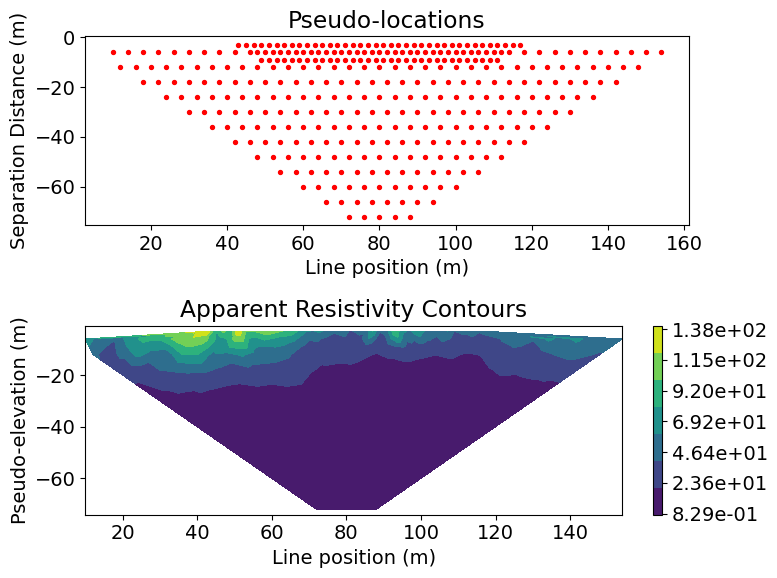

In [8]:
# Survey used Wenner configuration, so I will keep the default wenner_tolerance
pseudo_locations_xz = pseudo_locations(survey)
# print(len(pseudo_locations_xz))

# Plot pseudo-section
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

ax[0].scatter(pseudo_locations_xz[:, 0], pseudo_locations_xz[:, -1], 8, "r") # access pseudo_locations_xz depths [midxy, depth]
ax[0].set_xlabel("Line position (m)")
ax[0].set_ylabel("Separation Distance (m)")
ax[0].set_title("Pseudo-locations")

# Plot pseudosections of the apparent resistivity 
plot_pseudosection(
    data=survey,
    dobs=resist_data,
    data_type="volt",
    plot_type="contourf",
    data_location=True,
    ax=ax[1]
)

ax[1].set_title("Apparent Resistivity Contours")

plt.tight_layout()
plt.show()


Data appears to be concentrated more shallowly. Therefore, my confidence with depth the inversion with decrease. 

### Histogram of Data

np.float64(1065.1676672702315)

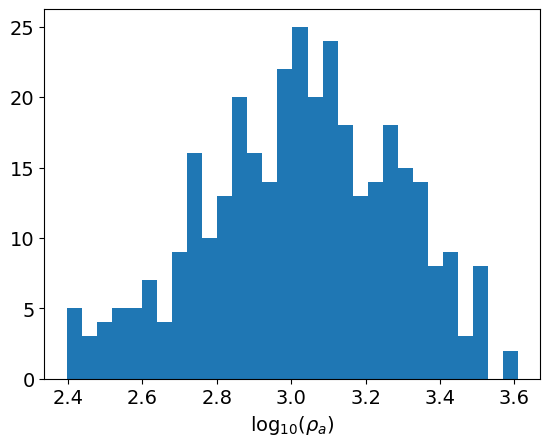

In [9]:
# calculate apparent resistivity
apparent_resistivity = apparent_resistivity_from_voltage(survey=survey, volts=resist_data, space_type="half space")

fig, ax = plt.subplots(1, 1)
out = ax.hist(np.log10(apparent_resistivity), bins=30)
ax.set_xlabel("log$_{10}(\\rho_a)$")

## Estimate a background model
# rho0 = 10**np.mean(np.log10(apparent_resistivity))
rho0 = np.median(apparent_resistivity)
rho0

## Setting Up Forward Problem

### Designing a Mesh

In [10]:
### Design a tree mesh ###

min_elec_space = 2 # minimum electrode spacing from metadata
min_cell_width = 2  # min cell width one-tenth of minimum electrode space

# find max electrode spacing (A - B)
max_AB = np.abs(a_loc[:, 0] - b_loc[:, 0]).max()

print(f"The maximum electrode spacing is: {max_AB} m")

The maximum electrode spacing is: 144.0 m


# of cells: 2059
# of x-faces: 2080
Origin: [ -50. -256.]
Max cell volume: 1024.0
[[ -34. -240.]
 [  -2. -240.]
 [ -42. -216.]
 [ -26. -216.]
 [ -42. -200.]]


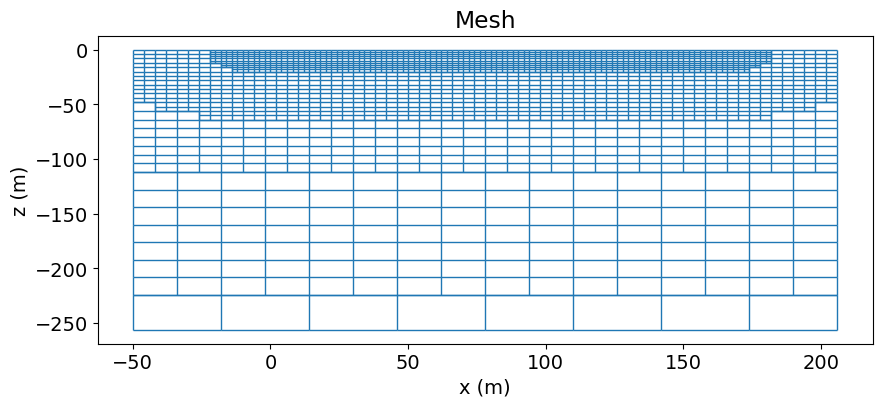

In [11]:
padding = 3 * max_AB # padding thickness should be about 2-3 times electrode spacing
domain_width_x = 250 # horizontal (x) domain width ≈ max electrode spacing + padding
domain_width_z = 2 * max_AB  # defines how deep mesh will go --> depth ≈ 2–3 × maximum electrode spacing
num_base_cell_x = 2 ** int(np.round(np.log(domain_width_x / min_cell_width) / np.log(2.0)))  # number of horizontal base cells
num_base_cell_z = 2 ** int(np.round(np.log(domain_width_z / min_cell_width) / np.log(2.0)))  # number of vertical base cells

# Define the base mesh with top at z = 0 m.
hx = [(min_cell_width, num_base_cell_x)]
hz = [(min_cell_width, num_base_cell_z)]

mesh = TreeMesh([hx, hz], origin=[max_AB/2-num_base_cell_x+6,-2*num_base_cell_z], diagonal_balance=True) # "C" = centered in x, "N" = top aligned in z
# Extract unique electrode locations.
unique_locations = survey.unique_electrode_locations

# Mesh refinement near electrodes.
mesh.refine_points(
    # use padding_cells_by_level to create a graded mesh (fine --> coarser) outward from electrodes
    # do this since sensitivity is closest near the electrodes
    unique_locations, padding_cells_by_level=[10, 10, 6, 6], finalize=False
)

mesh.finalize()

# Print mesh properties
print("# of cells: {}".format(mesh.n_cells))  # Number of cells
print("# of x-faces: {}".format(mesh.n_faces_x))  # Number of x-faces
print("Origin: {}".format(mesh.origin))  # bottom-southewest corner
print("Max cell volume: {}".format(mesh.cell_volumes.max()))  # Largest cell size
print(mesh.cell_centers[0:5, :])  # Cell center locations

# Plot mesh
fig, ax1 = plt.subplots(figsize=(10, 4))
mesh.plot_grid(ax=ax1, linewidth=1)
ax1.grid(False)
ax1.set_title("Mesh")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

plt.show()


### Define the Model

In [12]:
# Define model for following case: the model consists of the log-resistivity values for all active cells

# Get topo array from dictionary
topo_2d = dc_data_dict["topography"]

# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_2d)

# Number of active cells
num_active_cells = np.sum(active_cells)

### Define the Forward Simulation

In [13]:
# Use Simulation2DNodel
# To fully define the forward simulation, we need to connect the simulation object to the survey, mesh and mapping from the model to the mesh

# Use Exponential Map: m = log(rho)
mapping = maps.ExpMap(mesh)

# Generate 2.5D DC problem
simulation_dc = dc.Simulation2DNodal(
    mesh, 
    rhoMap=mapping, 
    solver=Solver, 
    survey=survey,
    bc_type="Neumann",
    storeJ=True, # runs faster --> can use for smaller models

)


In [14]:
%time # prints CPU time and wall (real) time to see how "taxing" simulation was

CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 7.15 μs


### Validate Forward Simulation

1) Run a simulation over a half-space and see if the apparent resistivites computed from simulated data equal the true halfspace resistivity $\rho_0$.
2) Plot the percent error in the apparent resistivity and see if the error is less than the errors in data. If error is greater than 5%, check:
    - Boundary conditions - does the mesh extend far enough?
    - Discretization near source and receivers - is the cell resolution high enough near the electrodes?
    - Are we using enough filters?

In [15]:
# To check our mesh and forward simulation, we run a simulation over a half-space. 
# The apparent resistivities we compute from the simulated data should be equal to the true half-space resistivity.

# run the forward simulation over the half-space & plot apparent resistivities
num_mesh_cells = mesh.nC
halfspace_model = np.ones(num_mesh_cells) * np.log(rho0) # defines model for log-resistivity space
halfspace_data = simulation_dc.make_synthetic_data(halfspace_model) # gives data that would be measured if earth had model "halfspace_model"

Text(0.5, 0, 'x (m)')

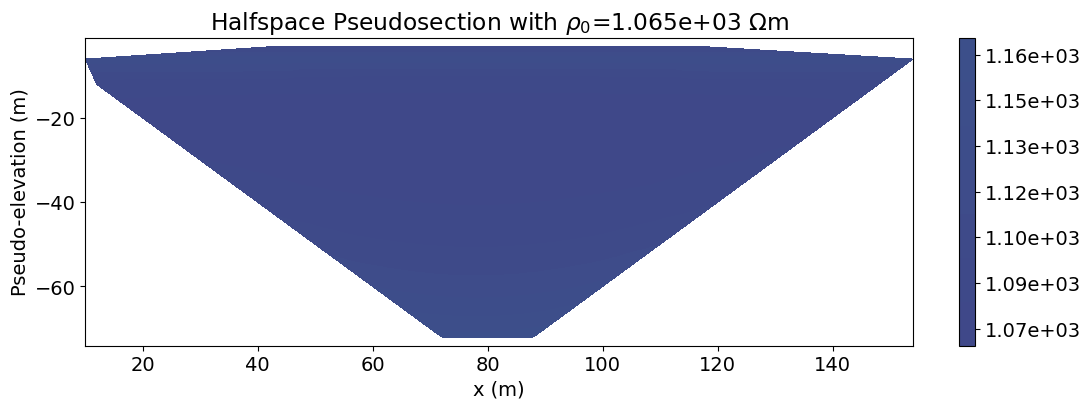

In [16]:
# plot halfspace psuedosection
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

clim = np.r_[apparent_resistivity.min(), apparent_resistivity.max()]
plot_pseudosection(
    halfspace_data, 
    data_type="apparent resistivity", 
    clim=clim,
    plot_type="contourf", 
    ax=ax,
)

ax.set_title(rf"Halfspace Pseudosection with $\rho_0$={rho0:.3e} $\Omega$m")
ax.set_xlabel("x (m)")

The above looks like a halfspace (no variation in apparent resistivities)! If we comment clim out, there is a bit more variability; however, there are only very slight deviations from $\rho_0$.

(<Axes: xlabel='Line position (m)', ylabel='Pseudo-elevation (m)'>,
 <matplotlib.tri._tricontour.TriContourSet at 0x7fbcf45e6f90>)

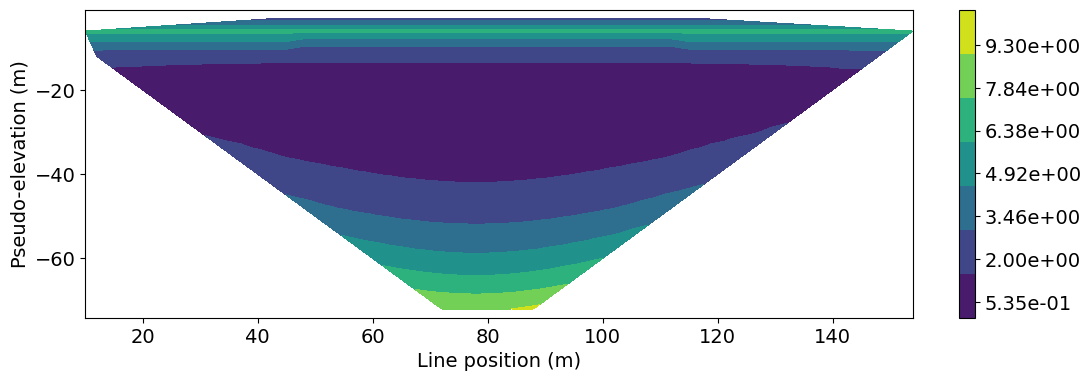

In [17]:
# Plot percent error
app_resistivity_halfspace_model = apparent_resistivity_from_voltage(halfspace_data.survey, halfspace_data.dobs)
percent_error = (app_resistivity_halfspace_model - rho0) / rho0 * 100
abs_error = np.abs(percent_error)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

plot_pseudosection(
    data=halfspace_data.survey,
    dobs=abs_error,
    data_type="apparent_resistivity",
    plot_type="contourf",
    ax=ax
)

It seems all percent errors are less than 5!

## DC Resistivity Inversion

### Choose Data Misfit

In [18]:
# Set up the data misfit, phid
# Use least-squares data misfit
phid_misfit = data_misfit.L2DataMisfit(data=dc_data, simulation=simulation_dc, debug=True)

### Choose Regularization

In [19]:
reg = regularization.WeightedLeastSquares(
    mesh,
    reference_model=halfspace_model,
    alpha_s=1.0, # scaling constant for the smallness regularization term --> use to scale the smallness tern based on cell size, not mesh
    alpha_x=0, 
    alpha_y=0,  # since this is a 2D problem, the second dimension is "y" 
)


### Choose Optimization Method 

In [32]:
opt = optimization.InexactGaussNewton(maxIter=3, maxIterCG=30)
inv_prob = inverse_problem.BaseInvProblem(phid_misfit, reg, opt)

/home/krista/miniconda3/envs/eosc-454/lib/python3.11/site-packages/simpeg/optimization.py:1061: FutureWarning: InexactCG.maxIterCG has been deprecated, please use InexactCG.cg_maxiter. It will be removed in version 0.26.0 of SimPEG.
  self.maxIterCG = val


### Assemble & Run Inversion

In [ ]:
# directives
beta_estimate = directives.BetaEstimate_ByEig(beta0_ratio=1e0)
# Use 2 for weakly non-linear optimization problems. 
# Use 3 for general non-linear optimization problems.
beta_schedule = directives.BetaSchedule(coolingFactor=4, coolingRate=2) # update beta

# save iterations
saved_output_dict = directives.SaveOutputDictEveryIteration()

# check betas
target = directives.TargetMisfit()

inv = inversion.BaseInversion(
    inv_prob, directiveList=[beta_estimate, beta_schedule, target, saved_output_dict]
)

In [34]:
# Run inversion
mopt = inv.run(halfspace_model) # set mref to halfspace model

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.0


INFO: Directive TargetMisfit: Target data misfit is 344.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  4.19e+00  2.88e+05  0.00e+00  2.88e+05                                 
   1  4.19e+00  6.29e+04  3.30e+03  7.68e+04    3.31e+04      0              
   2  4.19e+00  1.83e+04  4.74e+03  3.81e+04    1.61e+04      0              
   3  1.05e+00  5.98e+03  6.86e+03  1.32e+04    5.69e+03      0   Skip BFGS  
------------------------- STOP! -------------------------
1 : |fc-fOld| = 1.0068e+04 <= tolF*(1+|f0|) = 2.8757e+04
1 : |xc-x_last| = 1.4870e+01 <= tolX*(1+|x0|) = 3.1731e+01
0 : |proj(x-g)-x|    = 2.5343e+03 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 2.5343e+03 <= 1e3*eps       = 1.0000e-02
1 : maxIter   =       3    <= iter          =      3
------------------------- DONE! -------------------------


0.00027248039584677633


/tmp/ipykernel_1250/1264926015.py:12: UserWarning: plot_pseudosection unused kwargs: ['data_location']
  plot_pseudosection(


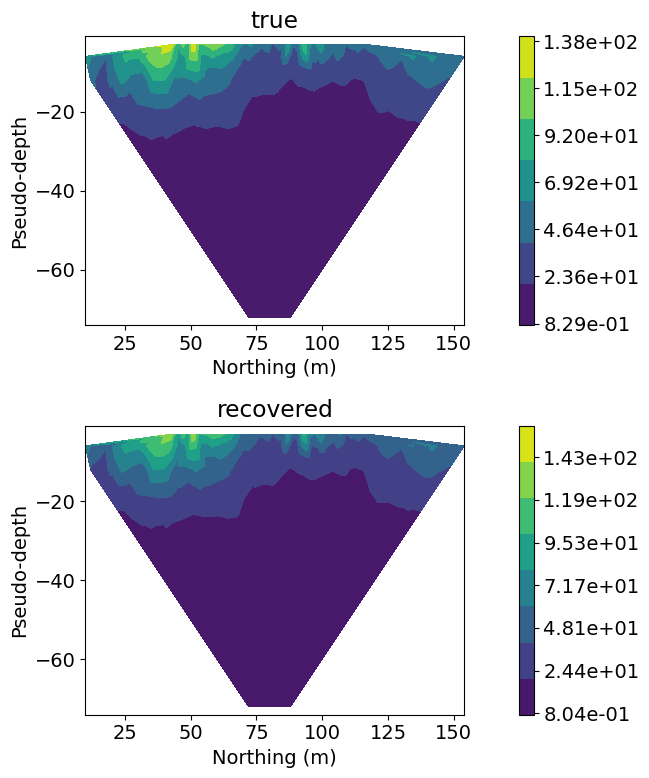

In [31]:
# plot pseudosection
print(inv_prob.beta)
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

clim = np.r_[apparent_resistivity.min(), apparent_resistivity.max()]

for a, data, title in zip(
    ax,
    [dc_data.dobs, inv_prob.dpred],
    ["true", "recovered"]
): 
    plot_pseudosection(
        dc_data, dobs=data, data_type="apparent resistivity",
        plot_type="contourf", data_location=True, ax=a, 
        # cbar_opts={"pad":0.25}, clim=clim
    )
    a.set_title(title)


for a in ax: 
    a.set_aspect(1.5)  # some vertical exxageration
    a.set_xlabel("Northing (m)")
    a.set_ylabel("Pseudo-depth")

plt.tight_layout()

/tmp/ipykernel_1250/1550550177.py:7: UserWarning: plot_pseudosection unused kwargs: ['data_location']
  plot_pseudosection(


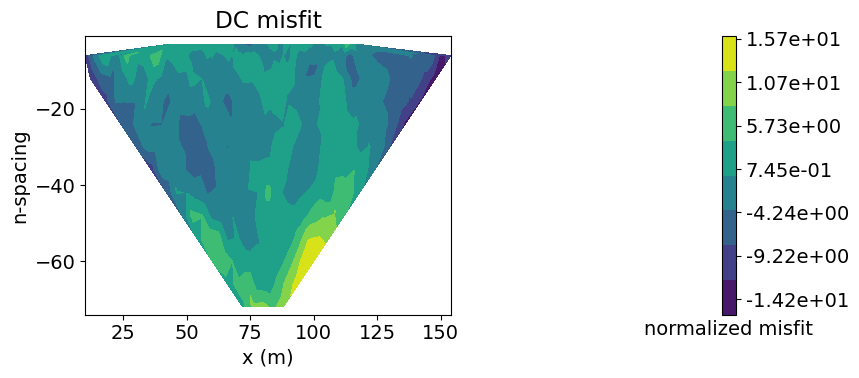

In [35]:
# Plot misfit
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# look at difference b/w predicted and measured data and normalize it by the standard deviation
normalized_misfit = (inv_prob.dpred - dc_data.dobs) / dc_data.standard_deviation 

plot_pseudosection(
    dc_data, dobs=normalized_misfit, data_type="misfit",
    plot_type="contourf", data_location=True, ax=ax, 
    cbar_opts={"pad":0.25}
)

ax.set_title("DC misfit")
ax.set_aspect(1.5)  # some vertical exxageration
ax.set_xlabel("x (m)")
ax.set_ylabel("n-spacing")

cb_axes = plt.gcf().get_axes()[-1]
cb_axes.set_xlabel('normalized misfit')

plt.tight_layout()

### Show Subsurface Resisitivity Model

/tmp/ipykernel_1250/450211598.py:3: FutureWarning: TreeMesh.plotImage has been deprecated, please use TreeMesh.plot_image. It will be removed in version 1.0.0 of discretize.
  out = mesh.plotImage(
/home/krista/miniconda3/envs/eosc-454/lib/python3.11/site-packages/discretize/utils/code_utils.py:315: FutureWarning: pcolorOpts has been deprecated, please use pcolor_opts
  return getattr(self, new_name)(*args, **kwargs)


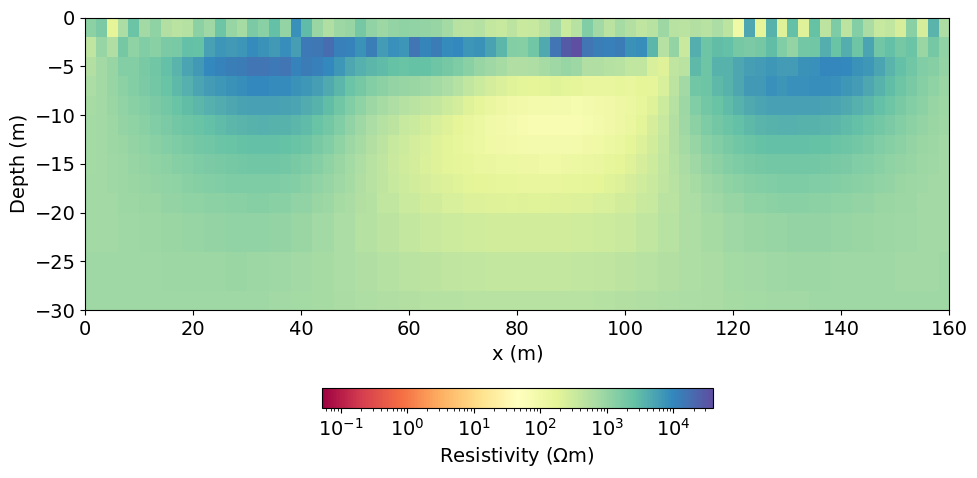

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
rho = (mapping*mopt) # converts from log model to physical resistivity (Ω·m)
out = mesh.plotImage(
    rho, 
    pcolorOpts={'norm':LogNorm(), 'cmap':'Spectral'}, # puts resistivity on log scale and uses a spectral colour map
    ax=ax,
)
ax.set_xlim((0, 160))
ax.set_ylim((-30, 0))
cb = plt.colorbar(out[0], fraction=0.05, orientation='horizontal', ax=ax, pad=0.2)
cb.set_label("Resistivity ($\Omega$m)")
ax.set_xlabel('x (m)')
ax.set_ylabel('Depth (m)')
plt.tight_layout()

### Plot Tikhonov Curves

In [50]:
# Get dictionary of each iteration input
iterations_dict = saved_output_dict.outDict

pu.plot_tikhonov_curves(dictionary=iterations_dict, target=target)



AttributeError: module 'project_utils' has no attribute 'plot_tikhonov_curves'

In [46]:
# initalize arrays
betas = []
phi_ms = []
phi_ds = []

# Get dictionary of each iteration input
iterations_dict = saved_output_dict.outDict

# get list of iterations done
list_iterations = iterations_dict.keys()

for i in list_iterations:
    betas.append(iterations_dict[i]['beta'])
    phi_ms.append(iterations_dict[i]['phi_m'])
    phi_ds.append(iterations_dict[i]['phi_d'])


print(iterations_dict)
print(betas)
print(target.target)

# fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# pu.plot_beta(inversion_results, ax=ax[0])
# pu.plot_misfit_and_regularization(inversion_results, ax=ax[1])
# pu.plot_regularization_components(inversion_results, ax=ax[2])
# ax[2].set_xlabel("iteration")


{1: {'iter': 1, 'beta': 4.191143411867315, 'phi_d': np.float64(62926.09412609697), 'phi_m': np.float64(3299.6257693636153), 'f': np.float64(76755.29893099291), 'm': array([6.97070312, 6.9705309 , 6.97044445, ..., 6.92962784, 6.92632372,
       6.93013197], shape=(2059,)), 'dpred': array([ 67.35505206,  34.17259188,  79.5532917 ,  26.63226585,
        20.94586844,  63.61312441,  56.05519574, 207.34797101,
        14.81436988,  76.73907761,  10.10961169, 226.12822688,
        15.41781153,  53.6630558 ,  14.15799033, 311.17394259,
        30.43430164,  11.05059577,  18.11981544,  46.0443758 ,
       317.68322288,  38.43101103,   8.93405742,   5.58808967,
       100.29838749,  17.4482963 ,  29.70597094,   7.00311547,
       282.69024918,   5.89946114,  79.53508673,  14.35569712,
         9.22482067,   4.82751575,  26.25092115, 168.49864889,
       180.40485028,  10.98260757,   5.49409633,  35.68976383,
        66.02222325,   4.7924931 ,  18.42901214,  48.02260612,
         7.8350879 ,  71.